In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

In [5]:
titanic = sns.load_dataset('titanic')

In [7]:
titanic.dropna(subset=['age', 'embarked'], inplace=True)

In [8]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [11]:
# 원핫인코딩
titanic = pd.get_dummies(titanic, columns = ['sex', 'embarked', 'class'], drop_first=True)

In [13]:
X = titanic.drop(['survived','deck','alone','who','adult_male','alive','embark_town'], axis = 1)

In [14]:
X = X*1

In [15]:
y=titanic['survived']

In [17]:
## 훈련데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 111)

In [18]:
# 모델 학습
model = LogisticRegression()

In [19]:
X

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,class_Second,class_Third
0,3,22.0,1,0,7.2500,1,0,1,0,1
1,1,38.0,1,0,71.2833,0,0,0,0,0
2,3,26.0,0,0,7.9250,0,0,1,0,1
3,1,35.0,1,0,53.1000,0,0,1,0,0
4,3,35.0,0,0,8.0500,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
885,3,39.0,0,5,29.1250,0,1,0,0,1
886,2,27.0,0,0,13.0000,1,0,1,1,0
887,1,19.0,0,0,30.0000,0,0,1,0,0
889,1,26.0,0,0,30.0000,1,0,0,0,0


In [20]:
#SequentialFeatureSelector
#SFS(모델을 선정할 때, 어떤 방법으로 선정할지, 선정방법, scoring = 어떤 평가로 볼건지?, cv = 교차검증 값)

sfs_forward = SFS(model, k_features = 'best', forward=True, floating=False, scoring='accuracy', cv=3)
sfs_backward = SFS(model, k_features = 'best', forward=False, floating=False, scoring='accuracy', cv=3)
sfs_stepwise = SFS(model, k_features = 'best', forward=True, floating=True, scoring='accuracy', cv=3)

# 각 방법을 학습하고 확인해보기
sfs_forward_f = sfs_forward.fit(X_train, y_train)
sfs_backward_f = sfs_backward.fit(X_train, y_train)
sfs_stepwise_f = sfs_stepwise.fit(X_train, y_train)

D:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via 

In [23]:
# 선택된 특성을 출력
print('sfs_forward 피처 출력', sfs_forward_f.k_feature_names_)
print('sfs_backward 피처 출력', sfs_backward_f.k_feature_names_)
print('sfs_stepwise 피처 출력', sfs_stepwise_f.k_feature_names_)

sfs_forward 피처 출력 ('pclass', 'age', 'sibsp', 'sex_male', 'embarked_S')
sfs_backward 피처 출력 ('pclass', 'age', 'sibsp', 'sex_male', 'embarked_S')
sfs_stepwise 피처 출력 ('pclass', 'age', 'sibsp', 'fare', 'sex_male', 'embarked_S', 'class_Third')


Text(0.5, 1.0, 'sfs_stepwise')

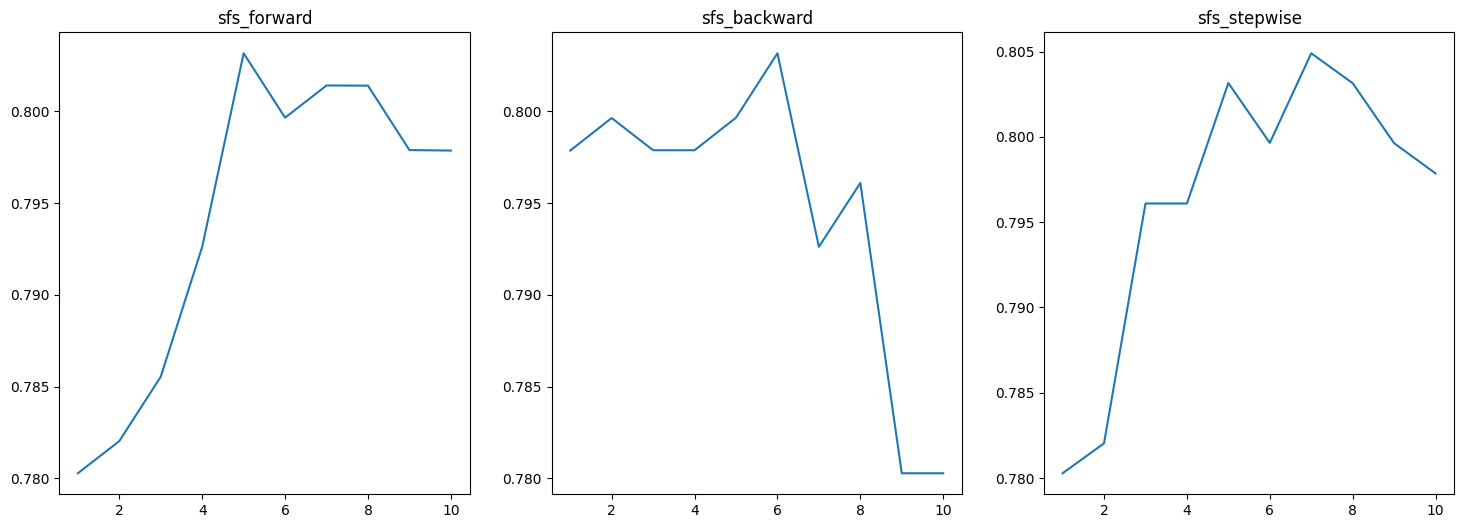

In [27]:
# 시각화를 통해서 피처를 선택했을 때 어떤 식의 평가가 나오는지

fig, ax = plt.subplots(1,3, figsize = (18,6))
ax[0].plot(range(1, len(sfs_forward_f.subsets_)+1),[sfs_forward_f.subsets_[i]['avg_score']for i in sfs_forward_f.subsets_],)
ax[0].set_title('sfs_forward')

ax[1].plot(range(1, len(sfs_backward_f.subsets_)+1),[sfs_backward_f.subsets_[i]['avg_score']for i in sfs_backward_f.subsets_],)
ax[1].set_title('sfs_backward')

# fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[2].plot(range(1, len(sfs_stepwise_f.subsets_)+1),[sfs_stepwise_f.subsets_[i]['avg_score']for i in sfs_stepwise_f.subsets_],)
ax[2].set_title('sfs_stepwise')

### RFE
- RFE모델을 사용해서 특성의 중요도를 평가
        - 모델은 회귀나 분류
        - 타겟변수에 영향을 미치는 것들을 측정하는 것
    - 순차적 특성 제거:
        - 처음에는 전체 특성을 사용해 모델읗 학습하고, 특성의 중요도 또는 가중치를 평가히야 중요도가 낮은 특성을 하나씩 제거한다.
        - 특성을 제거 할때 마다 모델을 다시 학습 시키면서 가장 중요하지 않은 것은 찾아내고 원하는 수의 특성만 남긴다
    - 반복적인 제거 과정 : 
        - 지정된 특정 수까지 반복적으로 학습과 제거를 수행
    - 하이퍼파라미터
        - estimator : 특성의 중요도 모델을 평가할 때 지정하는 것, 속성을 여러가지로 볼 수 있음
        - n_feature_to_select :피처를 선택할 수 있다.
        - step : 반복하면서 제거할 특성 수 step =1 1번에 2개 제거 이런 식으로 비율로도 제거 가능함

### RFECV
- 확장된 버전으로 교차검정을 통해서 최적의 특성 수를 자동으로 결정, 반복해서 특성을 제거하면서 교차검증까지 수행하여 모델 평가 -> 특성의 수를 찾는다 (자동으로 특성의 수를 찾아줌)
- 하이퍼파라미터
    - min_feature_to_select - 최소 선택될 특성 수
    - cv교차검증 분할수
    - scoring 모델 성능에 대한 평가지표
- 공통적으로 사용하는 함수
    - ranking_특성 중요도
    - support_ 선택된 특성이 True
    - n_features_ 선택된 특성의 개수
    - estimator_ 학습 완료된 상태 정보 확인


In [29]:
X, y = load_iris(return_X_y=True)

In [30]:
model = LogisticRegression()

In [31]:
selector=RFE(estimator= model, n_features_to_select=2)
selector = selector.fit(X, y)

D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
print('선택된 특성 출력해봐!', selector.support_)

선택된 특성 출력해봐! [False False  True  True]


In [35]:
print('선택된 특성 출력해봐!', selector.ranking_)

선택된 특성 출력해봐! [3 2 1 1]


In [36]:
## REFCV
## 교차검증이 필요하다

model = RandomForestClassifier()
cv = StratifiedKFold(3)

selector = RFECV(estimator=model, step=1, cv=cv)
selector = selector.fit(X, y)

In [37]:
print('최적의 수', selector.n_features_)
print('최적의 수', selector.support_)

최적의 수 2
최적의 수 [False False  True  True]


In [38]:
## RFECV 교차검증이 가능하니 여러 모델을 돌려서 비교해보자!

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [41]:
titanic = sns.load_dataset('titanic')
titanic.dropna(subset=['age', 'embarked'], inplace=True)

## 
titanic=pd.get_dummies(titanic, columns = ['sex','embarked','class'], drop_first=True)

X =titanic.drop(['survived','deck','alone','who','adult_male','alive','embark_town'], axis =1)
X=X*1
y = titanic['survived']

In [42]:
# 훈련 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 111)

In [43]:
from sklearn.svm import SVC

In [56]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 독립변수와 종속변수 설정
X = titanic.drop(['survived','deck','alone','who','adult_male','alive','embark_town'], axis=1)
y = titanic['survived']

# 훈련 및 테스트 데이터셋으로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 111)

# 모델 정의
models = {
    'LogisticRegression' : LogisticRegression(max_iter = 200),
    'RandomForestClassifier' : RandomForestClassifier(),
    'SVC' : SVC(kernel = 'linear')
}

# 교차 검증 설정
cv = StratifiedKFold(3)

# 결과를 정리할 DataFrame
results = pd.DataFrame(columns=['Model', 'Dataset', 'Accuracy', 'precision', 'Recall', 'F1', 'Selected Features'])

# 각 모델에 대해 RFECV 수행 및 결과 저장
for name, model in models.items():
    selector = RFECV(estimator = model, step=1, cv =cv, scoring = 'accuracy')
    selector.fit(X_train, y_train)

    # Train 및 Test 데이터 셋에 대한 평가
    for data in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        dataset_name, X_data, y_data = data
        y_pred = selector.predict(X_data)

        accuracy = accuracy_score(y_data, y_pred)
        precision = precision_score(y_data, y_pred)
        recall = recall_score(y_data, y_pred)
        f1 = f1_score(y_data, y_pred)
        
        selected_features = ','.join(X.columns[selector.support_])

        # 결과를 DataFrame에 추가
        result_row = pd.DataFrame({
        'Model' : [model],
        'Dataset' : [dataset_name],
        'Accuracy' : [accuracy],
        'Precision' : [precision],
        'Recall' : [recall],
        'F1' : [f1],
        'Selected Features' : [selected_features]
        })
        results = pd.concat([results, result_row], ignore_index = True)
print(result)

D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Empty DataFrame
Columns: [Model, Dataset, Accuracy, precision, Recall, F1, Selected Features]
Index: []


In [57]:
results

,Model,Dataset,Accuracy,precision,Recall,F1,Selected Features,Precision
0,LogisticRegression(max_iter=200),Train,0.797891,NaN,0.704036,0.731935,"pclass,age,sibsp,parch,fare,sex_male,embarked_...",0.762136
1,LogisticRegression(max_iter=200),Test,0.825175,NaN,0.707692,0.786325,"pclass,age,sibsp,parch,fare,sex_male,embarked_...",0.884615
2,RandomForestClassifier(),Train,0.985940,NaN,0.968610,0.981818,"pclass,age,fare,sex_male,class_Third",0.995392
3,RandomForestClassifier(),Test,0.825175,NaN,0.738462,0.793388,"pclass,age,fare,sex_male,class_Third",0.857143
4,SVC(kernel='linear'),Train,0.780316,NaN,0.681614,0.708625,sex_male,0.737864
5,SVC(kernel='linear'),Test,0.776224,NaN,0.661538,0.728814,sex_male,0.811321
